In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file
with open("bio2d_21/seepage_flux_try.txt", "r") as file:
    lines = file.readlines()

# Extract time and value for only Rank 19
data = []
for line in lines:
    if "Rank 120:" in line:
        parts = line.strip().split(",")
        if len(parts) == 3:
            time = float(parts[1])
            value = float(parts[2])
            data.append((time, value))

# Convert to DataFrame
df = pd.DataFrame(data, columns=["time", "flux"])

# Keep only the last occurrence for each time
df_last = df.groupby("time", as_index=False).last()

import numpy as np

# Ensure the columns are 1D numpy arrays
time_vals = np.array(df_last["time"].values, dtype=float).flatten()
flux_vals = np.array(df_last["flux"].values, dtype=float).flatten()

plt.figure(figsize=(8, 4))
plt.plot(time_vals, flux_vals, linestyle='-')
plt.xlabel("Time")
plt.ylabel("Seepage Flux)")
plt.title("Last Seepage Flux per Time Step (Rank 19)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Load and Filter Rank 19 Data ---
with open("bio2d_21/seepage_flux_try.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines:
    if "Rank 120:" in line:
        parts = line.strip().split(",")
        if len(parts) == 3:
            try:
                time = float(parts[1])
                flux = float(parts[2])
                data.append((time, flux))
            except ValueError:
                continue  # skip malformed lines

df = pd.DataFrame(data, columns=["time", "flux"])
df_last = df.groupby("time", as_index=False).last()

# --- Step 2: Full Target Time Sequence (truncate here for example, use your full list in practice) ---
time_sequence = [0.0, 1e-08, 0.0015, 0.003, 0.0045000000000000005, 0.006, 0.0075, 0.009000000000000001, 0.0105, 0.012, 0.0135, 0.015, 0.0165, 0.018000000000000002, 0.0195, 0.021, 0.0225, 0.024, 0.025500000000000002, 0.027, 0.0285, 0.03, 0.0315, 0.033, 0.0345, 0.036000000000000004, 0.0375, 0.039, 0.0405, 0.042, 0.043500000000000004, 0.045, 0.0465, 0.048, 0.0495, 0.051000000000000004, 0.0525, 0.054, 0.0555, 0.057, 0.0585, 0.06, 0.0615, 0.063, 0.0645, 0.066, 0.0675, 0.069, 0.07050000000000001, 0.07200000000000001, 0.0735, 0.075, 0.0765, 0.078, 0.0795, 0.081, 0.0825, 0.084, 0.0855, 0.08700000000000001, 0.0885, 0.09, 0.0915, 0.093, 0.0945, 0.096, 0.0975, 0.099, 0.1005, 0.10200000000000001, 0.10350000000000001, 0.105, 0.1065, 0.108, 0.1095, 0.111, 0.1125, 0.114, 0.1155, 0.117, 0.11850000000000001, 0.12, 0.1215, 0.123, 0.1245, 0.126, 0.1275, 0.129, 0.1305, 0.132, 0.1335, 0.135, 0.1365, 0.138, 0.1395, 0.14100000000000001, 0.14250000000000002, 0.14400000000000002, 0.1455, 0.147, 0.1485, 0.15, 0.1515, 0.153, 0.1545, 0.156, 0.1575, 0.159, 0.1605, 0.162, 0.1635, 0.165, 0.1665, 0.168, 0.1695, 0.171, 0.17250000000000001, 0.17400000000000002, 0.17550000000000002, 0.177, 0.1785, 0.18, 0.1815, 0.183, 0.1845, 0.186, 0.1875, 0.189, 0.1905, 0.192, 0.1935, 0.195, 0.1965, 0.198, 0.1995, 0.201, 0.2025, 0.20400000000000001, 0.20550000000000002, 0.20700000000000002, 0.2085, 0.21, 0.2115, 0.213, 0.2145, 0.216, 0.2175, 0.219, 0.2205, 0.222, 0.2235, 0.225, 0.2265, 0.228, 0.2295, 0.231, 0.2325, 0.234, 0.23550000000000001, 0.23700000000000002, 0.23850000000000002, 0.24, 0.2415, 0.243, 0.2445, 0.246, 0.2475, 0.249, 0.2505, 0.252, 0.2535, 0.255 , 0.2565, 0.258, 0.2595, 0.261, 0.2625] # , 0.264, 0.2655, 0.267, 0.2685, 0.27, 0.2715, 0.273, 0.2745, 0.276, 0.2775, 0.279, 0.2805, 0.28200000000000003, 0.28350000000000003, 0.28500000000000003, 0.28650000000000003, 0.28800000000000003, 0.2895, 0.291, 0.2925, 0.294, 0.2955, 0.297, 0.2985, 0.3]

# --- Step 3: Align to time_sequence ---
# Create a dictionary from df_last
flux_dict = dict(zip(df_last["time"].round(6), df_last["flux"]))

# Match values or assign 0
flux_aligned = [flux_dict.get(round(t, 6), 0.0) for t in time_sequence]

# --- Step 4: Plot ---
plt.figure(figsize=(10, 4))
plt.plot(time_sequence, flux_aligned, linestyle='-')
plt.xlabel("Time [s]")
plt.ylabel("Seepage Flux")
plt.title("Seepage Flux vs Time )")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\12254\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\12254\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


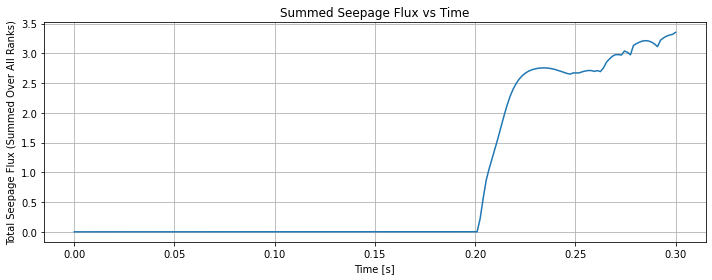

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# --- Step 1: Load and Parse All Ranks ---
with open("seepage_flux_try.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines:
    if "Rank" in line:
        parts = line.strip().split(",")
        try:
            rank = int(parts[0].split(":")[0].split()[1])
            time = float(parts[1])
            flux = float(parts[2])
            data.append((rank, time, flux))
        except (IndexError, ValueError):
            continue  # skip malformed lines

df = pd.DataFrame(data, columns=["rank", "time", "flux"])

# --- Step 2: Take Last Value per Rank per Time ---
df_last = df.groupby(["rank", "time"], as_index=False).last()

# --- Step 3: Sum Across Ranks for Each Time ---
df_total = df_last.groupby("time", as_index=False)["flux"].sum()

# --- Step 4: Align to Full Time Sequence ---
# Replace this with your full time sequence if needed
time_sequence = [0.0, 1e-08, 0.0015, 0.003, 0.0045, 0.006, 0.0075, 0.009, 0.0105, 0.012,
                 0.0135, 0.015, 0.0165, 0.018, 0.0195, 0.021, 0.0225, 0.024, 0.0255, 0.027,
                 0.0285, 0.03, 0.0315, 0.033, 0.0345, 0.036, 0.0375, 0.039, 0.0405, 0.042,
                 0.0435, 0.045, 0.0465, 0.048, 0.0495, 0.051, 0.0525, 0.054, 0.0555, 0.057,
                 0.0585, 0.06, 0.0615, 0.063, 0.0645, 0.066, 0.0675, 0.069, 0.0705, 0.072,
                 0.0735, 0.075, 0.0765, 0.078, 0.0795, 0.081, 0.0825, 0.084, 0.0855, 0.087,
                 0.0885, 0.09, 0.0915, 0.093, 0.0945, 0.096, 0.0975, 0.099, 0.1005, 0.102,
                 0.1035, 0.105, 0.1065, 0.108, 0.1095, 0.111, 0.1125, 0.114, 0.1155, 0.117,
                 0.1185, 0.12, 0.1215, 0.123, 0.1245, 0.126, 0.1275, 0.129, 0.1305, 0.132,
                 0.1335, 0.135, 0.1365, 0.138, 0.1395, 0.141, 0.1425, 0.144, 0.1455, 0.147,
                 0.1485, 0.15, 0.1515, 0.153, 0.1545, 0.156, 0.1575, 0.159, 0.1605, 0.162,
                 0.1635, 0.165, 0.1665, 0.168, 0.1695, 0.171, 0.1725, 0.174, 0.1755, 0.177,
                 0.1785, 0.18, 0.1815, 0.183, 0.1845, 0.186, 0.1875, 0.189, 0.1905, 0.192,
                 0.1935, 0.195, 0.1965, 0.198, 0.1995, 0.201, 0.2025, 0.204, 0.2055, 0.207,
                 0.2085, 0.21, 0.2115, 0.213, 0.2145, 0.216, 0.2175, 0.219, 0.2205, 0.222,
                 0.2235, 0.225, 0.2265, 0.228, 0.2295, 0.231, 0.2325, 0.234, 0.2355, 0.237,
                 0.2385, 0.24, 0.2415, 0.243, 0.2445, 0.246, 0.2475, 0.249, 0.2505, 0.252,
                 0.2535, 0.255, 0.2565, 0.258, 0.2595, 0.261, 0.2625, 0.264, 0.2655, 0.267,
                 0.2685, 0.27, 0.2715, 0.273, 0.2745, 0.276, 0.2775, 0.279, 0.2805, 0.282,
                 0.2835, 0.285, 0.2865, 0.288, 0.2895, 0.291, 0.2925, 0.294, 0.2955, 0.297,
                 0.2985, 0.3]

# Create lookup for summed values
flux_dict = dict(zip(df_total["time"].round(6), df_total["flux"]))

# Match or assign 0
flux_aligned = [flux_dict.get(round(t, 6), 0.0) for t in time_sequence]

# --- Step 5: Plot Total Seepage Flux Across All Ranks ---
plt.figure(figsize=(10, 4))
plt.plot(time_sequence, flux_aligned, linestyle='-')
plt.xlabel("Time [s]")
plt.ylabel("Total Seepage Flux (Summed Over All Ranks)")
plt.title("Summed Seepage Flux vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()


## Pipe Outflow

### Pipe Capacity
$Q= AR^{2/3}S^{1/2} $

- For circular Pipe
A= $\frac{\pi D^2}{4}$, R = $\frac{D}{4}$
- For Rectangular Pipe(Our simulation)

A= $Height * Width$ , R= W+ 2*Height

S= Slope

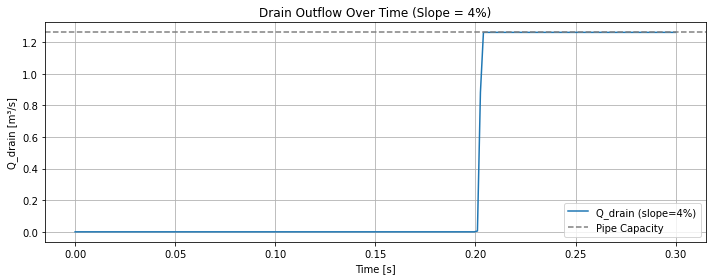

In [3]:
# Parameters for the rectangular pipe
pipe_width = 0.5       # m (from previous geometry)
pipe_height = 0.5      # m
pipe_length = 4.0      # m (as requested)
pipe_n = 0.012         # Manning's n (smooth pipe)

# Two slope values for comparison
slopes = [0.04]  # Only 4% slope requested

# Function to compute Manning-limited flow for a rectangular pipe
def manning_rectangular_pipe_flow(width, height, slope, n=0.012):
    A = width * height
    P = width + 2 * height
    R = A / P
    return (1 / n) * A * R**(2/3) * slope**0.5

# Time and flux assumed already defined from prior context
# If not, replace with actual data or dummy values
#time_sequence = np.linspace(0, 1, 100)  # Dummy if not defined
#flux_aligned = np.linspace(0, 5e-5, 100)  # Dummy if not defined
Q_drain_raw = np.array(flux_aligned) * pipe_length  # from seepage

# Create plots for each slope
for slope in slopes:
    Q_pipe_max = manning_rectangular_pipe_flow(pipe_width, pipe_height, slope, pipe_n)
    Q_drain = np.minimum(Q_drain_raw, Q_pipe_max)

    # Plot outflow per time
    plt.figure(figsize=(10, 4))
    plt.plot(time_sequence, Q_drain, label=f"Q_drain (slope={int(slope*100)}%)")
    plt.axhline(Q_pipe_max, color='gray', linestyle='--', label='Pipe Capacity')
    plt.xlabel("Time [s]")
    plt.ylabel("Q_drain [m³/s]")
    plt.title(f"Drain Outflow Over Time (Slope = {int(slope*100)}%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


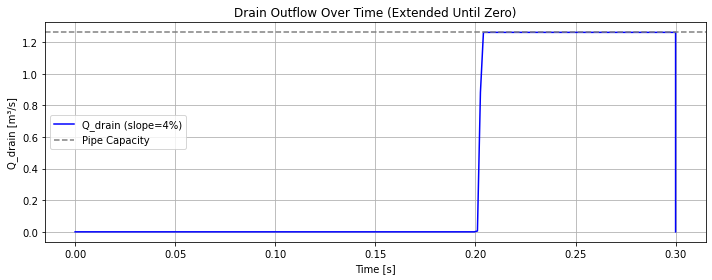

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz

# Placeholder seepage flux data (replace with real values if needed)
#time_sequence = np.linspace(0, 0.3, 100)
#flux_aligned = np.linspace(0, 5e-5, 100)

# Pipe parameters
pipe_width = 0.5  # m
pipe_height = 0.5  # m
pipe_length = 4.0  # m
pipe_n = 0.012
pipe_slope = 0.04  # 4% slope

# Manning capacity for rectangular pipe
def manning_rectangular_pipe_flow(width, height, slope, n=0.012):
    A = width * height
    P = width + 2 * height
    R = A / P
    return (1 / n) * A * R**(2/3) * slope**0.5

Q_pipe_max = manning_rectangular_pipe_flow(pipe_width, pipe_height, pipe_slope, pipe_n)

# Compute raw and capped outflow
Q_drain_raw = np.array(flux_aligned) * pipe_length
Q_drain = np.minimum(Q_drain_raw, Q_pipe_max)

# Cumulative volume to find when to stop
V_drain = cumtrapz(Q_drain, time_sequence, initial=0.0)
V_final = V_drain[-1]
Q_last = Q_drain[-1]
time_last = time_sequence[-1]

# Extend time until all volume is drained
t_more = (V_final - V_drain[-1]) / Q_last if Q_last > 0 else 0
extra_time = np.linspace(time_last, time_last + t_more, 50)
extra_flow = np.maximum(Q_last - np.linspace(0, Q_last, 50), 0)
extra_volume = V_drain[-1] + cumtrapz(extra_flow, extra_time, initial=0.0)

# Concatenate extended time and flow
extended_time = np.concatenate((time_sequence, extra_time))
extended_flow = np.concatenate((Q_drain, extra_flow))

# Plot extended Q_drain
plt.figure(figsize=(10, 4))
plt.plot(extended_time, extended_flow, label=f"Q_drain (slope=4%)", color="blue")
plt.axhline(Q_pipe_max, color='gray', linestyle='--', label='Pipe Capacity')
plt.xlabel("Time [s]")
plt.ylabel("Q_drain [m³/s]")
plt.title("Drain Outflow Over Time (Extended Until Zero)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


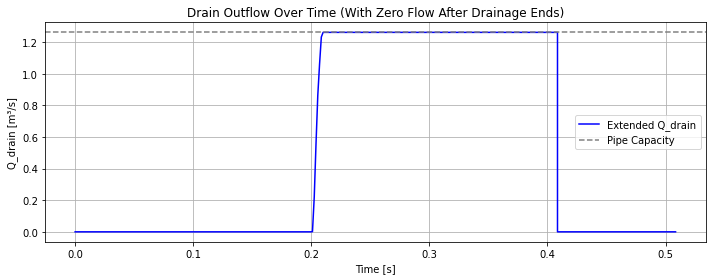

(0.25733580726, 0.2573358072600006, 100.00000000000024)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz

# Sample time and flux data
#time_sequence = np.linspace(0, 0.3, 100)
#flux_aligned = np.linspace(0, 5e-5, 100)

# Pipe parameters
pipe_width = 0.5
pipe_height = 0.5
pipe_length = 4.0
pipe_n = 0.012
pipe_slope = 0.04

# Manning's equation
def manning_rectangular_pipe_flow(width, height, slope, n=0.012):
    A = width * height
    P = width + 2 * height
    R = A / P
    return (1 / n) * A * R**(2/3) * slope**0.5

Q_pipe_max = manning_rectangular_pipe_flow(pipe_width, pipe_height, pipe_slope, pipe_n)

# Compute raw and capped drain flow
Q_drain_raw = flux_aligned #* pipe_length
Q_drain = np.minimum(Q_drain_raw, Q_pipe_max)

# Cumulative volumes
V_supplied = cumtrapz(Q_drain_raw, time_sequence, initial=0.0)
V_drained = cumtrapz(Q_drain, time_sequence, initial=0.0)
V_target = V_supplied[-1]
V_current = V_drained[-1]
V_remaining = V_target - V_current

# Time to drain remaining volume at max capacity
t_extra_needed = V_remaining / Q_pipe_max

# Extend time to drain and then drop to zero
extra_time = np.linspace(time_sequence[-1], time_sequence[-1] + t_extra_needed, 100)
extra_flow = np.full_like(extra_time, Q_pipe_max)

# Add two points of zero flow after draining completes
zero_time = np.linspace(extra_time[-1], extra_time[-1] + 0.1, 2)
zero_flow = np.zeros_like(zero_time)

# Concatenate full extended timeline
extended_time_fixed = np.concatenate((time_sequence, extra_time, zero_time))
extended_flow_fixed = np.concatenate((Q_drain, extra_flow, zero_flow))

# Final cumulative volume
V_drained_fixed = cumtrapz(extended_flow_fixed, extended_time_fixed, initial=0.0)
V_final_drained = V_drained_fixed[-1]
V_fraction = 100 * V_final_drained / V_target

# Plot
plt.figure(figsize=(10, 4))
plt.plot(extended_time_fixed, extended_flow_fixed, label="Extended Q_drain", color="blue")
plt.axhline(Q_pipe_max, color='gray', linestyle='--', label='Pipe Capacity')
plt.xlabel("Time [s]")
plt.ylabel("Q_drain [m³/s]")
plt.title("Drain Outflow Over Time (With Zero Flow After Drainage Ends)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

V_target, V_final_drained, V_fraction


C:\Users\12254\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\12254\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
C:\Users\12254\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


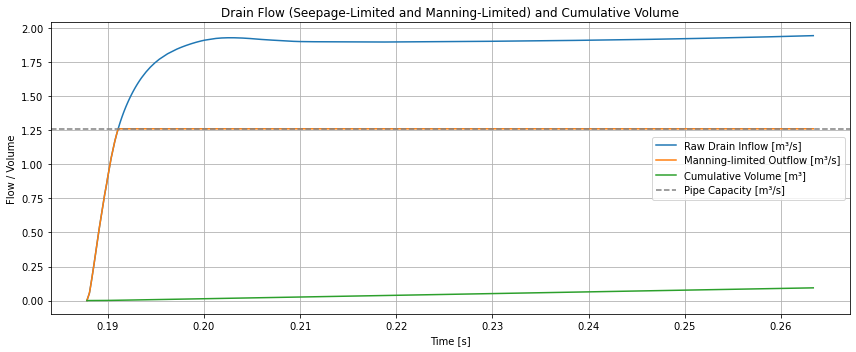

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import cumtrapz
import matplotlib.pyplot as plt
import math

# --- Load the seepage flux time series safely (line by line) ---
data = []
with open("bio2d_21/seepage_flux_try.txt", "r") as file:
    for line in file:
        if "Rank 120:" in line:
            parts = line.strip().split(",")
            if len(parts) == 3:
                try:
                    time = float(parts[1])
                    flux = float(parts[2])
                    data.append((time, flux))
                except ValueError:
                    continue  # skip malformed lines

df = pd.DataFrame(data, columns=["time", "flux"])
df_last = df.groupby("time", as_index=False).last()

# Time sequence
time_sequence = sorted(df_last["time"].unique())
flux_dict = dict(zip(df_last["time"].round(6), df_last["flux"]))
flux_aligned = np.array([flux_dict.get(round(t, 6), 0.0) for t in time_sequence])
time_sequence = np.array(time_sequence)

# --- Manning's Equation for Rectangular Pipe ---
def manning_rectangular_pipe_flow(width, height, slope, n=0.012):
    A = width * height
    P = width + 2 * height
    R = A / P
    Q = (1 / n) * A * R**(2/3) * slope**0.5
    return Q

# Pipe properties
pipe_width = 1.7 - 1.2   # 0.5 m
pipe_height = 1.9 - 1.4  # 0.5 m
pipe_slope = 0.04
pipe_n = 0.012
pipe_length = 30.0        # extent into third dimension

# Drain inflow and capacity-limited outflow
Q_drain_raw = flux_aligned #* pipe_length
Q_pipe_max = manning_rectangular_pipe_flow(pipe_width, pipe_height, pipe_slope, pipe_n)
Q_drain_limited = np.minimum(Q_drain_raw, Q_pipe_max)
V_drain = cumtrapz(Q_drain_limited, time_sequence, initial=0.0)

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(time_sequence, Q_drain_raw, label='Raw Drain Inflow [m³/s]')
plt.plot(time_sequence, Q_drain_limited, label='Manning-limited Outflow [m³/s]')
plt.plot(time_sequence, V_drain, label='Cumulative Volume [m³]')
plt.axhline(Q_pipe_max, color='gray', linestyle='--', label='Pipe Capacity [m³/s]')
plt.xlabel("Time [s]")
plt.ylabel("Flow / Volume")
plt.title("Drain Flow (Seepage-Limited and Manning-Limited) and Cumulative Volume")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Plot cumulative drain volume only
plt.figure(figsize=(10, 4))
plt.plot(time_sequence, Q_drain_raw, label='Cumulative Volume Drained [m³]', color='green')
plt.xlabel("Time [s]")
plt.ylabel("Cumulative Volume [m³]")
plt.title("Cumulative Drain Outflow Volume Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
# Compute incremental volume between time steps
V_stepwise = np.diff(V_drain, prepend=0.0)


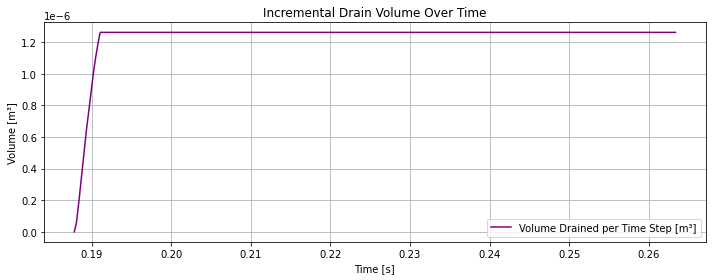

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(time_sequence, V_stepwise, label="Volume Drained per Time Step [m³]", color="purple")
plt.xlabel("Time [s]")
plt.ylabel("Volume [m³]")
plt.title("Incremental Drain Volume Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


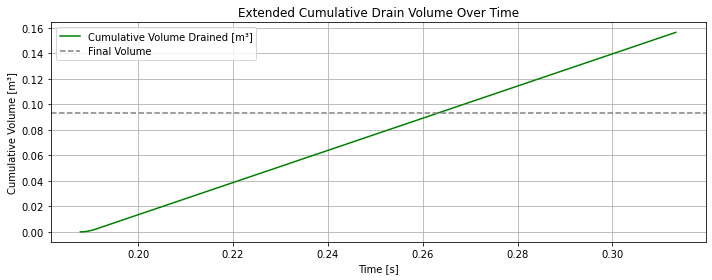

In [4]:
# Calculate the total volume that will eventually be drained (final value of cumulative volume)
V_final = V_drain[-1]

# Estimate when all water is drained by projecting at last outflow rate
Q_last = Q_drain_limited[-1]  # m³/s at final time
time_last = time_sequence[-1]
V_remaining = V_final - V_drain[-1]

# Time needed to finish draining if Q remains constant
if Q_last > 0:
    t_extension = (V_final - V_drain[-1]) / Q_last
else:
    t_extension = 0

# Extend time and volume arrays linearly if needed
extra_time = np.linspace(time_last, time_last + 0.05, 100)
extra_volume = V_drain[-1] + Q_last * (extra_time - time_last)

# Concatenate with original arrays
extended_time = np.concatenate((time_sequence, extra_time))
extended_volume = np.concatenate((V_drain, extra_volume))

# Plot extended cumulative volume
plt.figure(figsize=(10, 4))
plt.plot(extended_time, extended_volume, label="Cumulative Volume Drained [m³]", color="green")
plt.axhline(V_final, color='gray', linestyle='--', label='Final Volume')
plt.xlabel("Time [s]")
plt.ylabel("Cumulative Volume [m³]")
plt.title("Extended Cumulative Drain Volume Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
Q_pipe_max

1.2618893005778746

In [8]:
max(Q_drain_raw)

1.94628662